In [2]:
%load_ext autoreload
%autoreload 2

In [56]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup
from tqdm.notebook import tqdm
import scipy.signal 

In [4]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [5]:
patch_fs_c14 = 50023.8986874656




In [6]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
#get cell number 
cell_num = 'c14'


#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec


patch_channel = -patch_filt_c14


# IAP to inferred EAP

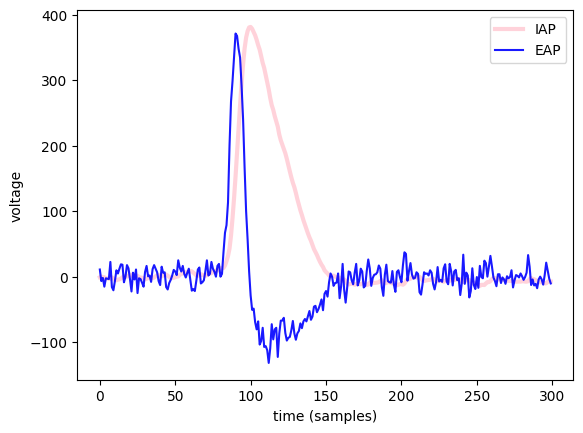

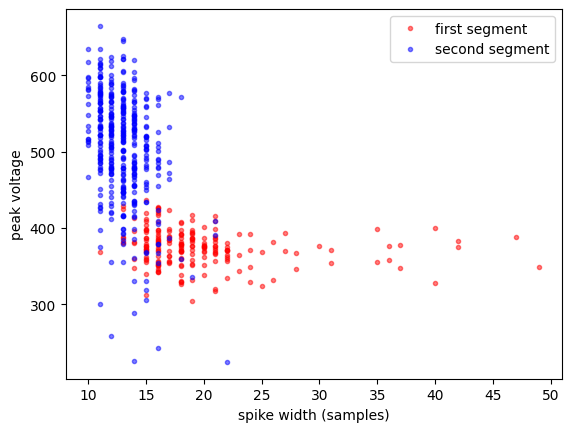

In [50]:


patch_fs = patch_fs_c14

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 10 # this is arbitrary, just to scale it better to the iap

first_segment = iap2eap[:3000000]
last_segment = iap2eap[51000000:54000000]


# show that the pseudo-eap works
plt.plot(patch_filt[21900:22200], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[21900:22200], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()




# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 200, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 200, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

### Check how the inferred EAPs compare to the actual EAPs

In [8]:
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c14npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = float(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109

In [9]:
# open and load the data
npx_filt = np.load(npx_path)

npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

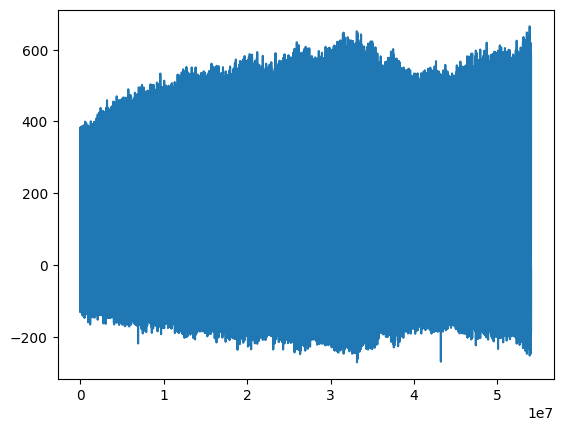

In [51]:
plt.plot(iap2eap)

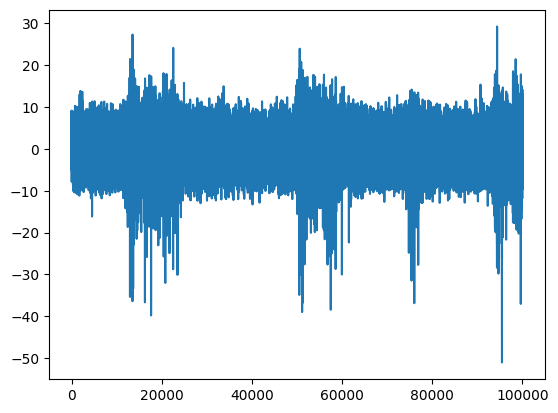

In [37]:
plt.plot(npx_filt[0:100000])

In [203]:
#Run spikeparam on real EAPs 
sp_ex = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1746 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


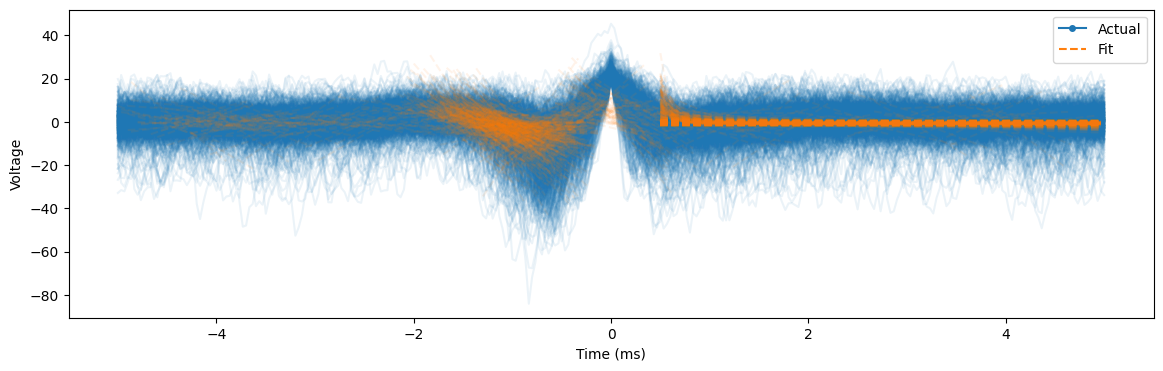

In [305]:
sp_ex.plot()

Text(0.5, 1.0, 'EAP rsq ramp')

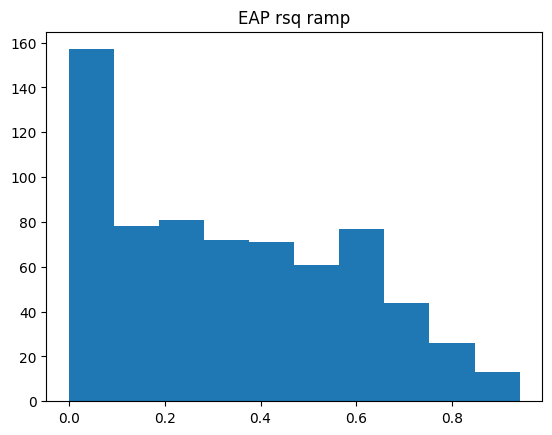

In [205]:
plt.hist(sp_ex.df_features['r_squared_ramp'])
plt.title("EAP rsq ramp")

Text(0.5, 1.0, 'EAP rsq exp')

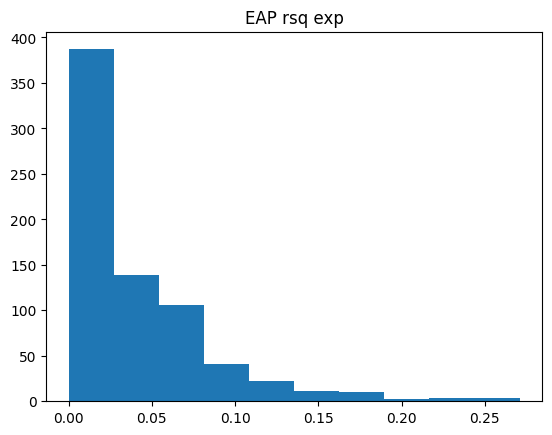

In [206]:
plt.hist(sp_ex.df_features['r_squared_exp'])
plt.title("EAP rsq exp")

In [207]:
sp_ex.spike_inds

array([   13538,    22556,    50608, ..., 32348023, 32377733, 32381129])

In [208]:
#clean detected EAP spikes 
df_features = sp_ex.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [209]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,original_index
0,0.078107,13.266667,-4.383741,27.339920,0.400000,8.461518,0.000058,-1.320736,300.600000,NaN,NaN,0
1,-21.831190,0.833333,-26.761189,24.145146,0.900000,8.756443,0.003411,-99.999999,935.066667,0.342498,0.006908,1
2,0.926717,12.200000,0.002766,23.952634,0.166667,15.230298,0.005537,-99.989587,1459.066667,NaN,NaN,2
3,0.134612,6.300000,-6.306877,29.265961,0.400000,7.607221,8.666148,-0.804461,137.333333,NaN,NaN,3
4,3.303903,0.266667,2.240679,21.435123,0.200000,9.633505,9.999983,0.506074,848.466667,0.113111,0.073496,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1741,-1.884371,10.466667,-7.425491,26.450478,0.533333,5.153338,0.000005,-0.276578,1042.733333,NaN,NaN,1741
1742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.700000,NaN,NaN,1742
1743,-18.579427,1.066667,-37.364995,20.866838,1.666667,10.928652,0.000005,-0.783132,990.333333,0.261565,0.029127,1743
1744,0.440013,9.266667,3.469463,24.505761,0.333333,4.388314,0.000485,-1.424933,113.200000,NaN,NaN,1744


In [210]:
# Step 1: Perform the filtering process on df_features ##SHOULD I CLEAN/FILTER OUT THE NPX SPIKES OR NOT??
df_features['original_index'] = df_features.index  # Save the original indices

# Apply filtering conditions
df_features = df_features[df_features['inflection_time'] > 0.]
df_features = df_features[df_features['inflection_time'] < 2.]
df_features = df_features[df_features['r_squared_exp'] >= .02]
df_features = df_features[df_features['r_squared_ramp'] >= .1]
df_features['log_isi'] = np.log10(df_features['isi'])  # log_isi calculation
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp', 'isi'], axis=1)

# Replace infinite values with NaN and drop rows with NaN values
df_features = df_features.replace([np.inf, -np.inf], np.nan).dropna()

# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)

# Compute the IQR for each feature
IQR = Q3 - Q1

# Define the multiplier for outlier removal (1.5 is typical, but you can adjust it)
outlier_thresh = 1.5

# Filter out rows that are outside of the acceptable IQR range
df_features= df_features[~((df_features < (Q1 - outlier_thresh * IQR)) | (df_features > (Q3 + outlier_thresh * IQR))).any(axis=1)]




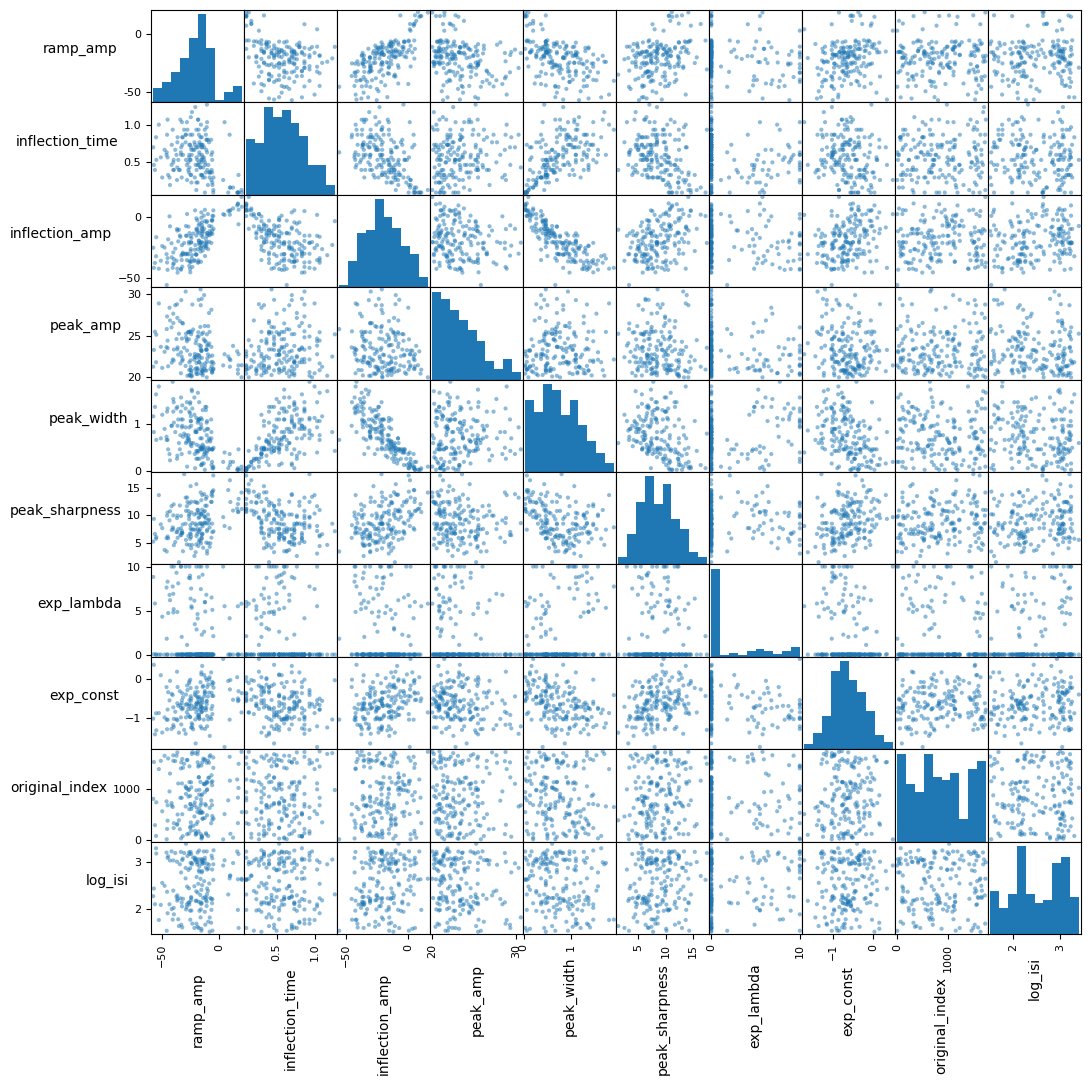

In [237]:
# Step 2: Get the cleaned spike indices based on the filtered df_features
cleaned_spike_indices = df_features['original_index'].values
cleaned_spike_indices = np.sort(np.unique(cleaned_spike_indices))  # Ensure indices are unique and sorted




axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

In [212]:
#Downsample inferred EAPs to match real EAP sampling rate
iap2eap = scipy.signal.resample(iap2eap, int((len(iap2eap)/patch_fs)*npx_fs))

In [213]:
len(iap2eap)

11653346

In [288]:
#Rescale inferred EAPs so that it matches real EAPs 
iap2eap_scaled = iap2eap/15 # this is arbitrary, just to scale it better to the iap# CHANGES DEPENDING ON WHAT IVE BEEN RUNNING 

iap2eap_times = np.arange(0, np.shape(iap2eap_scaled)[0]) / npx_one_ms # in ms instead of sec"""

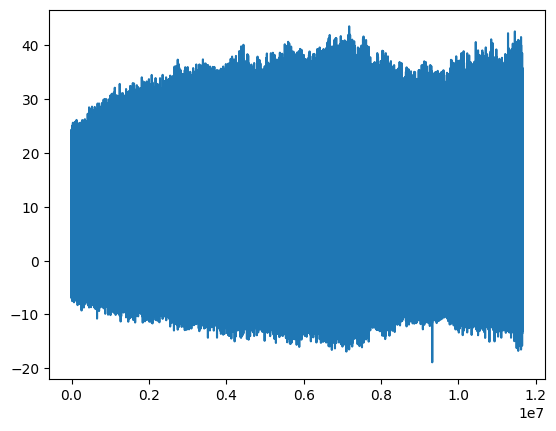

In [273]:
plt.plot(iap2eap_scaled)

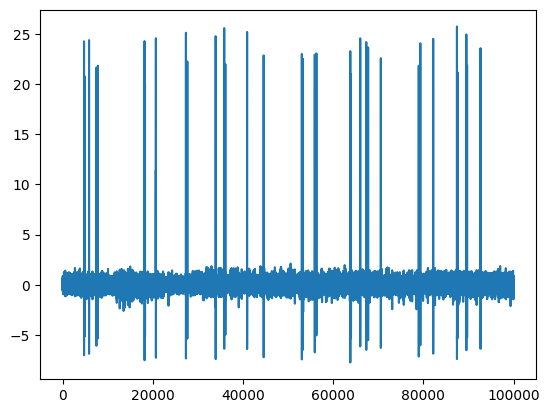

In [216]:
plt.plot(iap2eap_scaled[0:100000])

In [274]:
#Run spikeparam on inferred EAPs 

sp_ex_inf = Spike(thresh_amp= 20, window_length=(5., 5.), smooth_frac=.01)


sp_ex_inf.fit(iap2eap_scaled, npx_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/2781 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


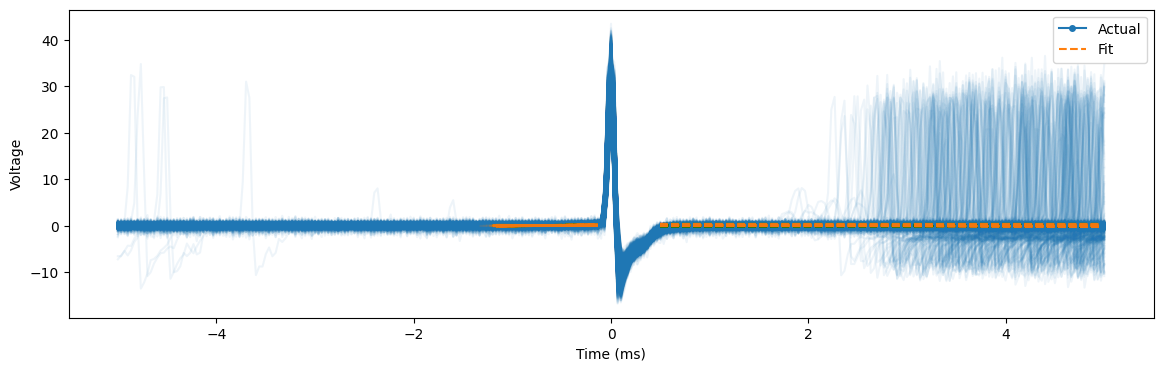

In [218]:
sp_ex_inf.plot(
)

#### Calculate coincident and extraneous spikes between real IAPs and real EAPs

In [219]:
#Run spikeparam on IAPs 

sp = Spike(thresh_amp=400, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3968 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


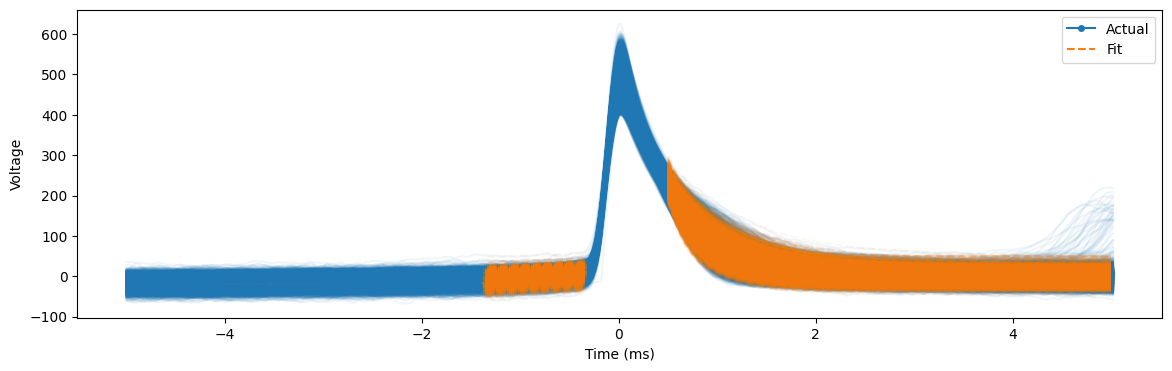

In [220]:
sp.plot()

In [289]:
sp_inds = sp.spike_inds


sp_inds_ms = patch_times_c14[sp.spike_inds]

sp_ex_inds= sp_ex.spike_inds[cleaned_spike_indices]

sp_ex_inds_ms = npx_times[sp_ex.spike_inds[cleaned_spike_indices]] 

sp_ex_inf_inds = sp_ex_inf.spike_inds

sp_ex_inf_inds_ms = iap2eap_times[sp_ex_inf.spike_inds]

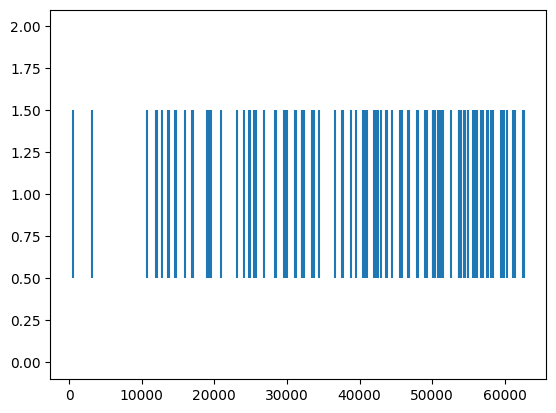

In [300]:
plt.eventplot(sp_inds_ms[0:100])

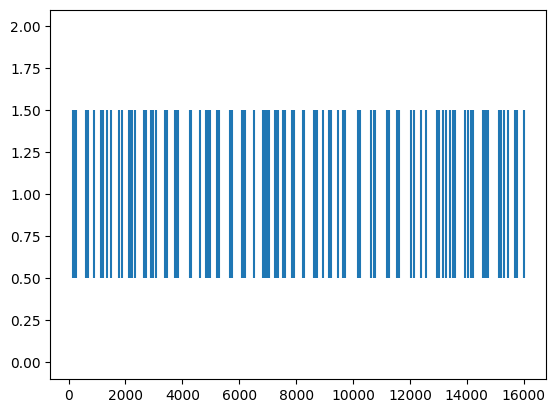

In [301]:
plt.eventplot(sp_ex_inf_inds_ms[0:100])

In [295]:
len(sp_inds_ms)

3968

In [297]:
len(sp_ex_inf_inds_ms)

2781

In [281]:
sp_ex_inds_ms

array([   3283.33333333,    4938.96666667,   10708.63333333,
         12815.4       ,   21874.53333333,   23137.1       ,
         34360.33333333,   40836.1       ,   42973.86666667,
         43642.33333333,   45752.3       ,   54346.13333333,
         57582.33333333,   57758.06666667,   59530.9       ,
         63663.3       ,   69036.23333333,   69086.06666667,
         70111.13333333,   72617.96666667,   93518.46666667,
         97695.76666667,  101497.83333333,  120728.        ,
        124091.6       ,  130720.43333333,  137465.16666667,
        152482.96666667,  160681.63333333,  171717.2       ,
        174441.26666667,  182924.1       ,  186528.06666667,
        193875.33333333,  195046.9       ,  195125.53333333,
        205904.03333333,  212006.1       ,  227987.56666667,
        235269.6       ,  241756.4       ,  254650.46666667,
        257578.83333333,  260247.4       ,  265123.53333333,
        286153.1       ,  290190.3       ,  302149.3       ,
        313271.1       ,

In [268]:
len(sp.spikes)

3968

In [267]:
len(sp_ex_inf.spikes)

2781

In [252]:
len(df_features)

171

In [261]:
df_features['original_index'].iloc[0]

4

In [304]:
coincidence_window = 2 # milliseconds

# Lists to store the coincident spike times and indices
coincident_eap_spikes = []
coincident_iap_spikes = []
coincident_eap_spike_num = []
coincident_iap_spike_num = []

# Initialize counters for the spike counts
coincident_count = 0
non_coincident_eap_count = 0
non_coincident_iap_count = 0

# Iterate through each EAP spike time
for sp_ex_counter, eap_spike_time in enumerate(sp_ex_inds_ms):
    coincident_found = False

    # Search for coincident IAP spikes within the time window
    for sp_counter, iap_spike_time in enumerate(sp_inds_ms):
        if abs(eap_spike_time - iap_spike_time) <= coincidence_window:
            coincident_count += 1
            coincident_found = True
            coincident_eap_spikes.append(eap_spike_time)  # Save coincident EAP spike time
            coincident_iap_spikes.append(iap_spike_time)  # Save coincident IAP spike time

            # Append the original spike indices (which are the counters in this case)
            coincident_eap_spike_num.append(int(df_features['original_index'].iloc[sp_ex_counter]))
            coincident_iap_spike_num.append(sp_counter)

            break  # Exit the inner loop once a coincident spike is found

    # If no coincident IAP spike is found, increment the non-coincident EAP count
    if not coincident_found:
        non_coincident_eap_count += 1

# Calculate the number of non-coincident IAP spikes
non_coincident_iap_count = len(sp_inds_ms) - coincident_count

# Print the results
print(f"Number of coincident spikes: {coincident_count}")
print(f"Number of non-coincident EAP spikes: {non_coincident_eap_count}")
print(f"Number of non-coincident IAP spikes: {non_coincident_iap_count}")


Number of coincident spikes: 44
Number of non-coincident EAP spikes: 127
Number of non-coincident IAP spikes: 3924


In [264]:
coincident_eap_spike_num 

[23, 104, 171, 312, 324, 535, 600, 656, 735, 937, 1108, 1573]

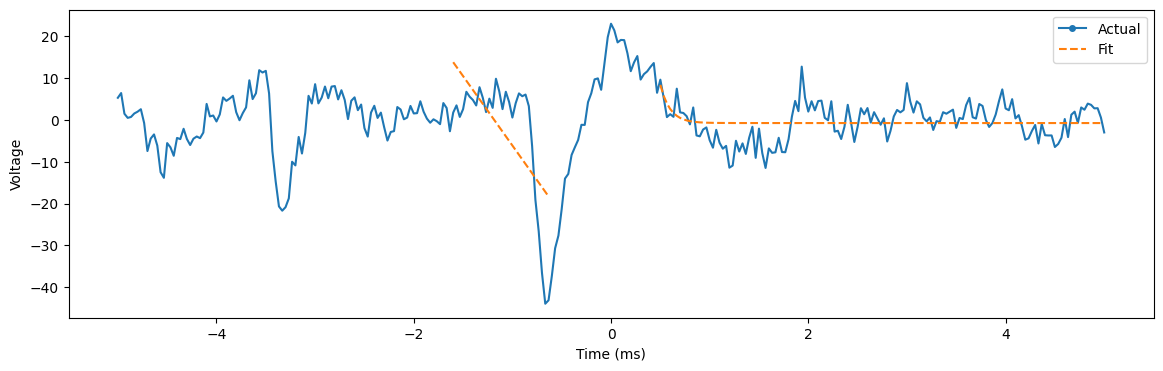

In [265]:
sp_ex.plot(23)

### Get indices for inferred eap coincident spikes 

In [303]:
coincidence_window = 2  # milliseconds

# List to store the matching inferred EAP spike times
matching_eap_inf_spikes = []

# Iterate through each IAP spike time
for iap_spike_time in sp_inds_ms:
    # Find any inferred EAP spike time within the coincidence window
    for eap_inf_spike_time in sp_ex_inf_inds_ms:
        if abs(iap_spike_time - eap_inf_spike_time) <= coincidence_window:
            matching_eap_inf_spikes.append(eap_inf_spike_time)
            break  # Stop searching once a match is found within the window

# Print or use the matching inferred EAP spike times
print(f"Matching inferred EAP spike times (ms): {matching_eap_inf_spikes}")


Matching inferred EAP spike times (ms): [25686.466666666667, 122690.7, 124932.43333333333, 138813.2, 142749.33333333334, 146830.23333333334, 162088.7, 180341.2, 194087.3, 200204.06666666668, 224030.86666666667, 250718.33333333334, 277151.3, 289945.13333333336, 294591.4, 300818.6, 369172.9666666667]


#### Plot coincident spikes

Plotting IAP spike at detected spike number: 5
Plotting EAP spike at detected spike number: 23
Plotting Inferred EAP spike at detected spike number: 5
Plotting IAP spike at detected spike number: 88
Plotting EAP spike at detected spike number: 104
Plotting Inferred EAP spike at detected spike number: 88
Plotting IAP spike at detected spike number: 186
Plotting EAP spike at detected spike number: 171
Plotting Inferred EAP spike at detected spike number: 186
Plotting IAP spike at detected spike number: 389
Plotting EAP spike at detected spike number: 312
Plotting Inferred EAP spike at detected spike number: 389
Plotting IAP spike at detected spike number: 406
Plotting EAP spike at detected spike number: 324
Plotting Inferred EAP spike at detected spike number: 406
Plotting IAP spike at detected spike number: 741
Plotting EAP spike at detected spike number: 535
Plotting Inferred EAP spike at detected spike number: 741
Plotting IAP spike at detected spike number: 837
Plotting EAP spike at 

/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/spikeparam/patch/plts/plts.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(figsize=(14, 4))


IndexError: index 3465 is out of bounds for axis 0 with size 2781

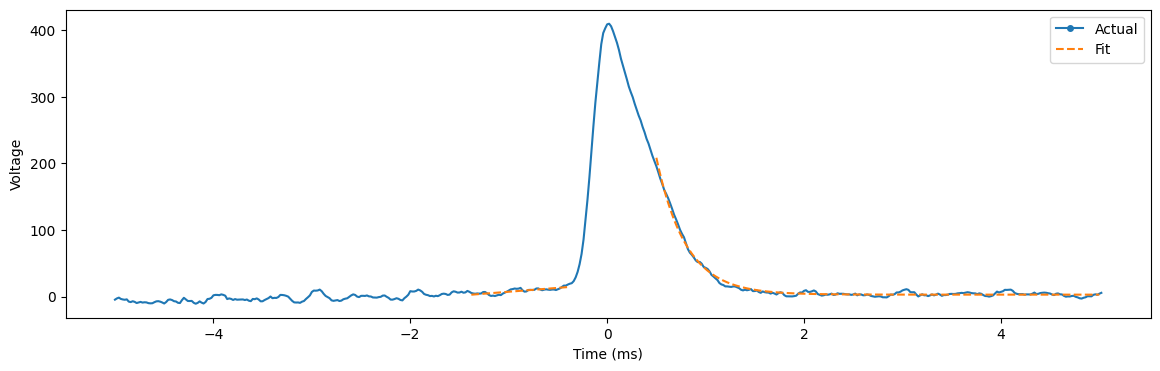

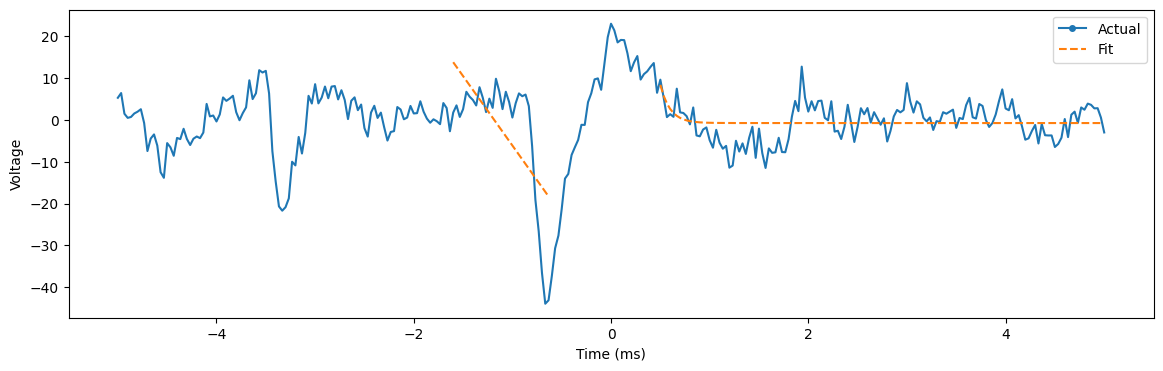

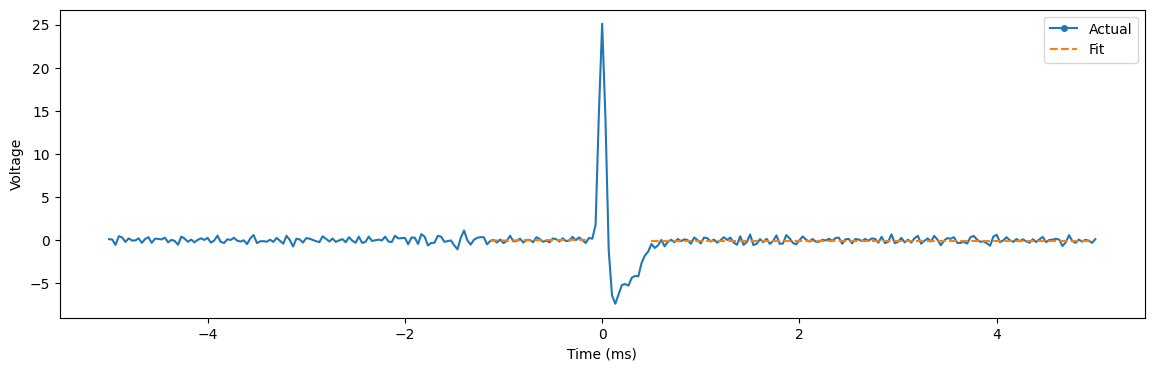

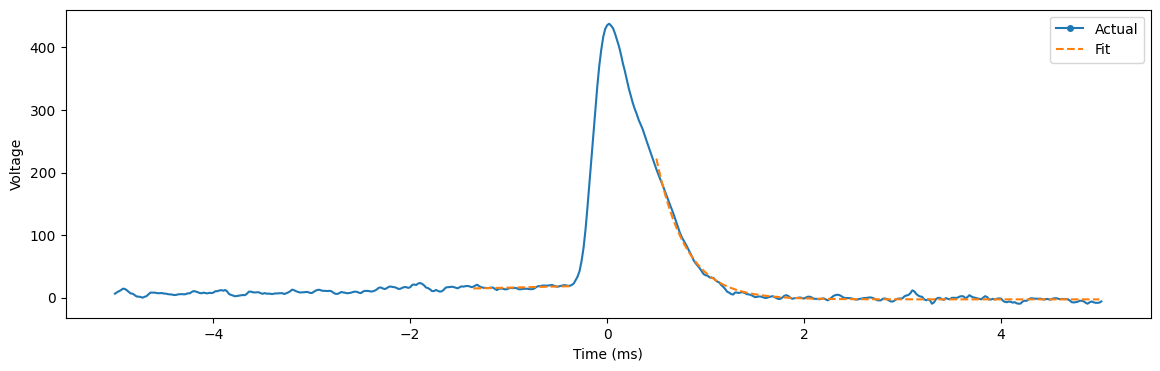

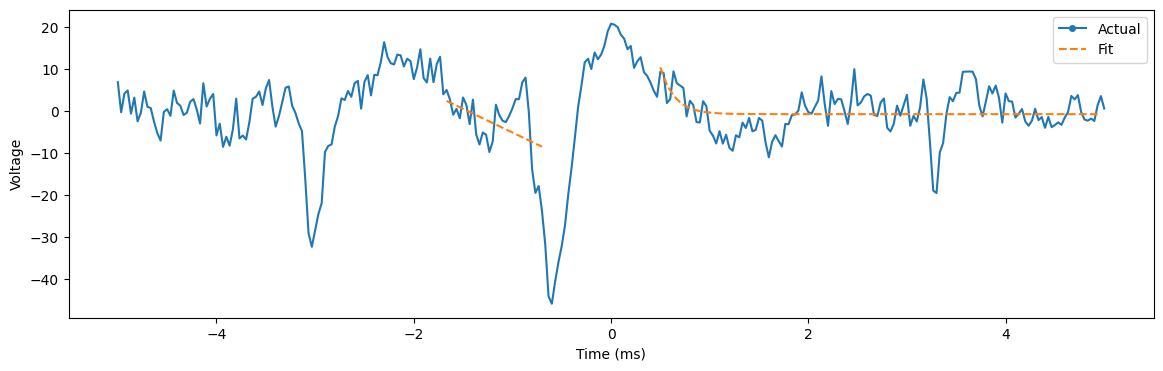

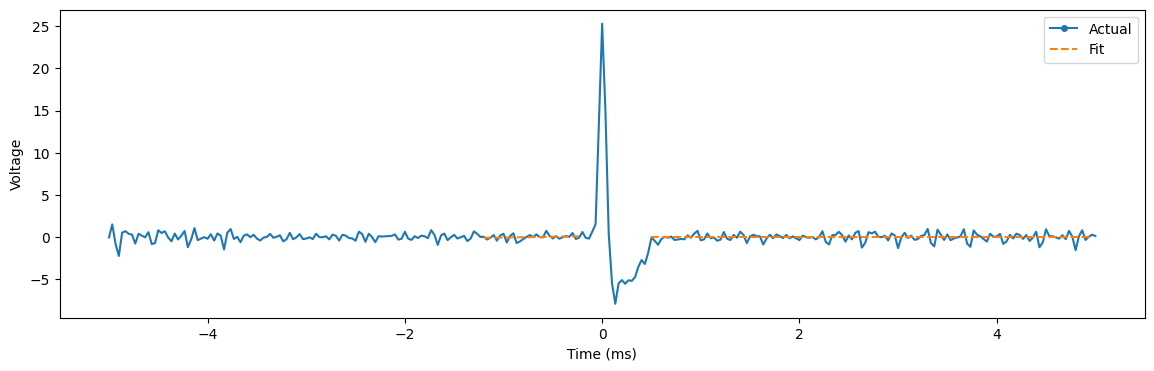

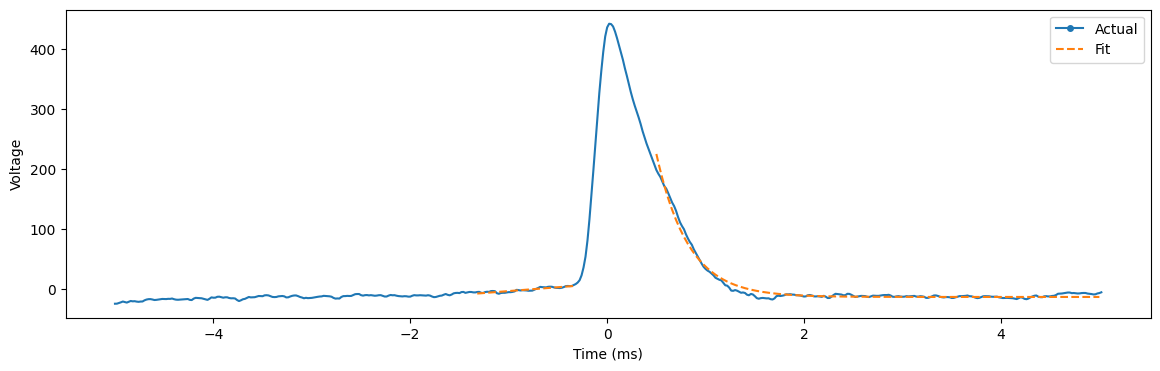

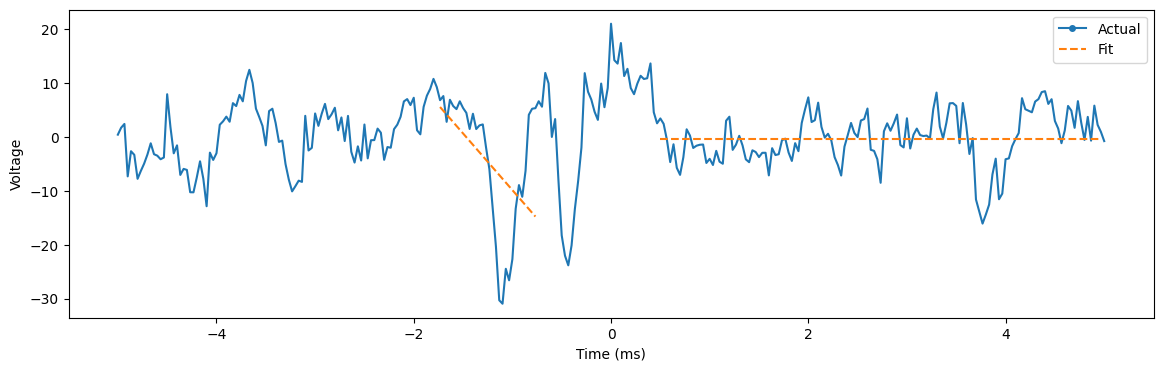

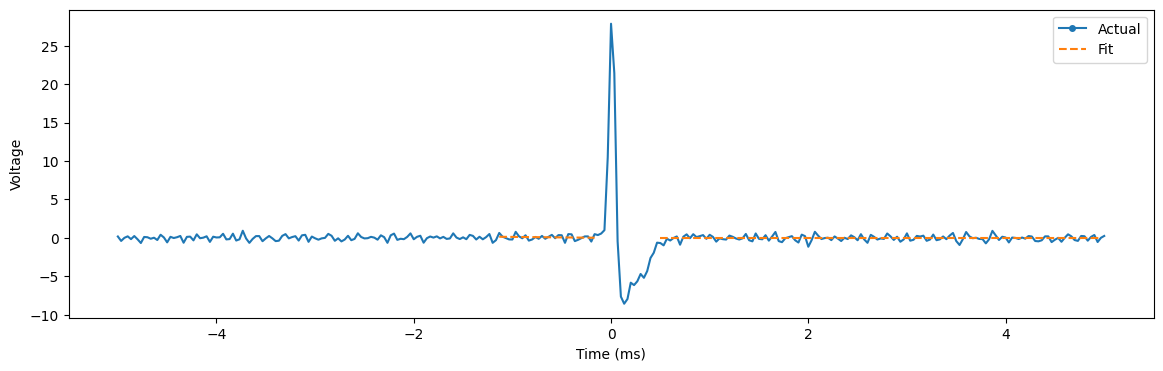

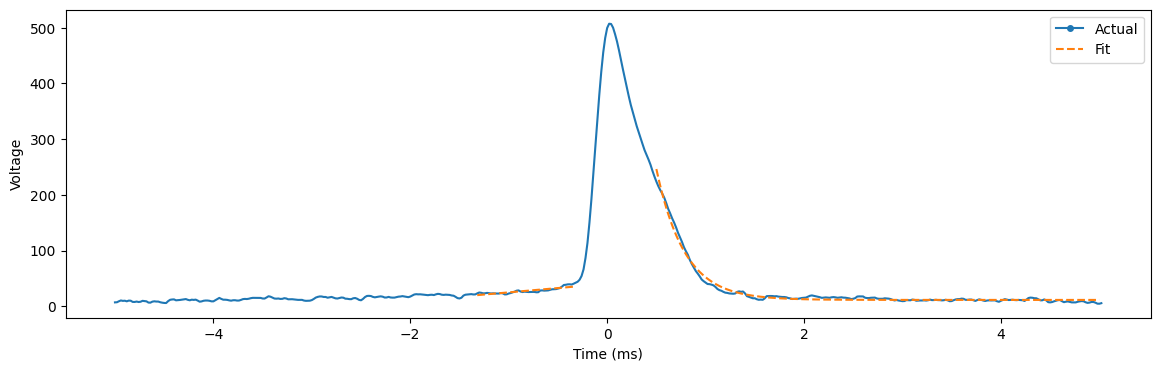

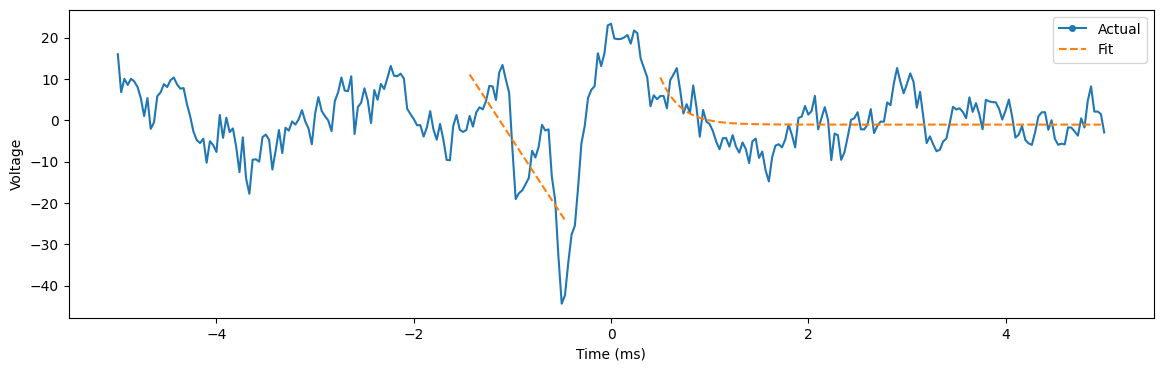

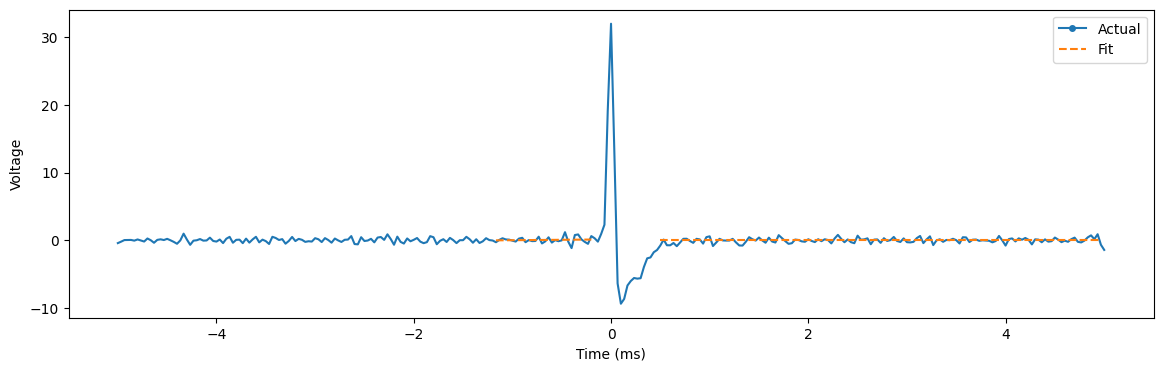

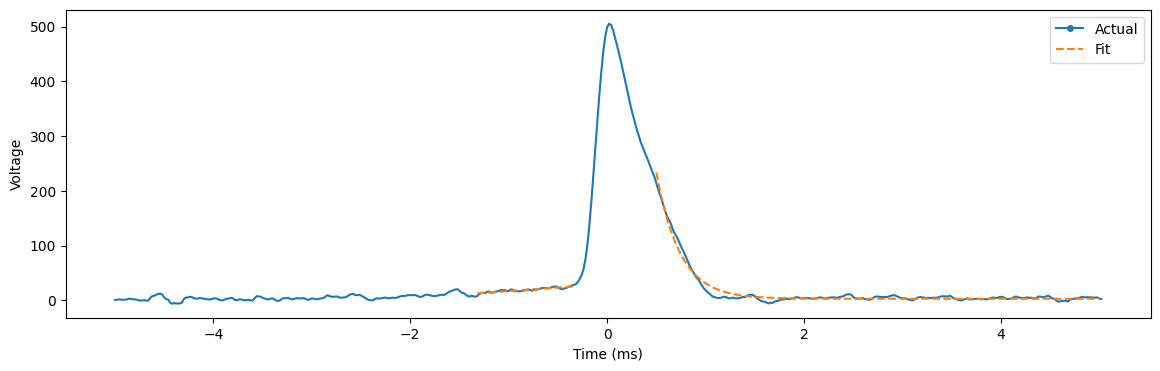

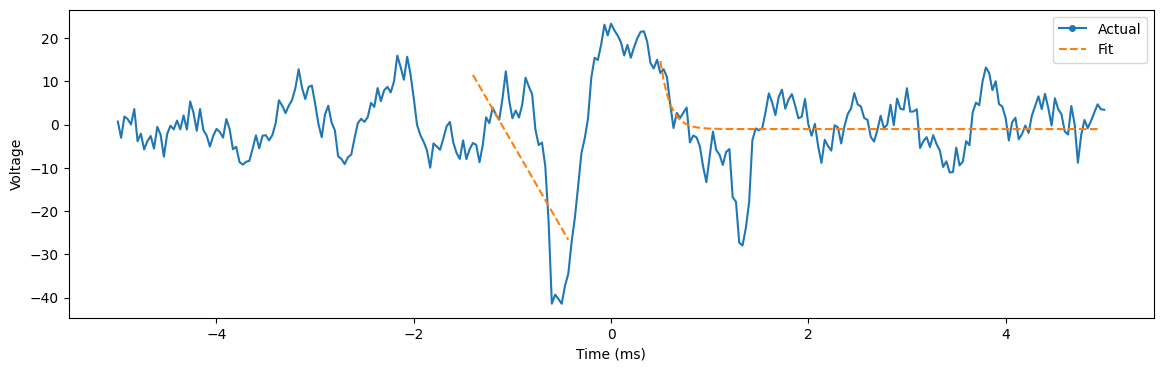

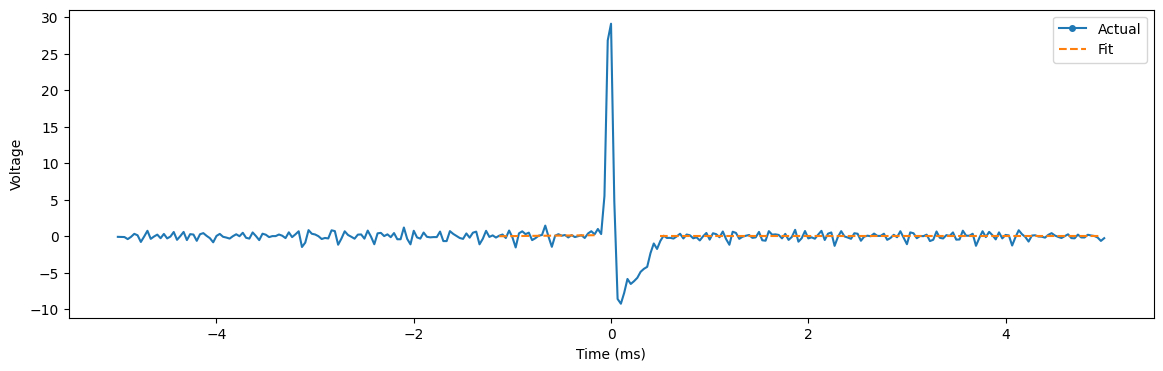

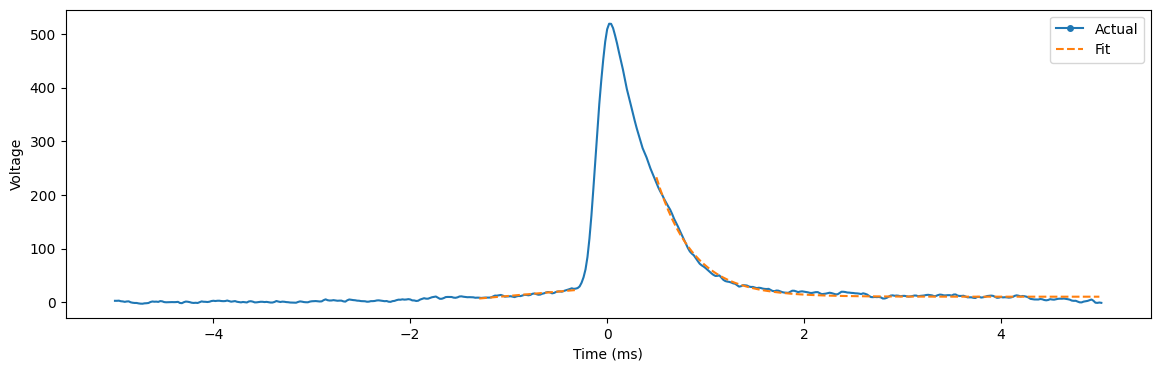

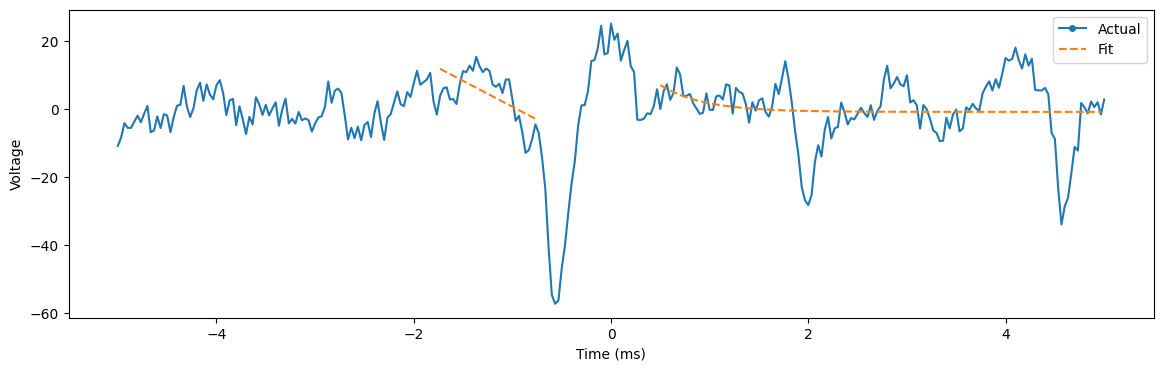

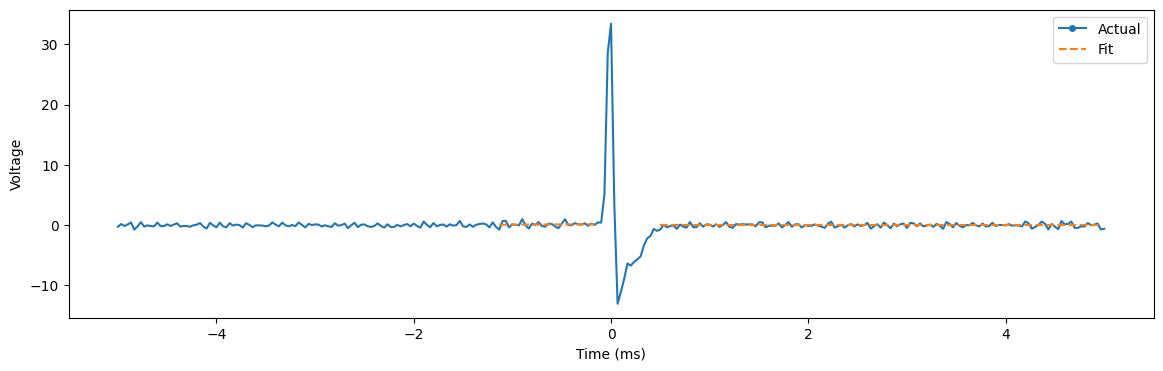

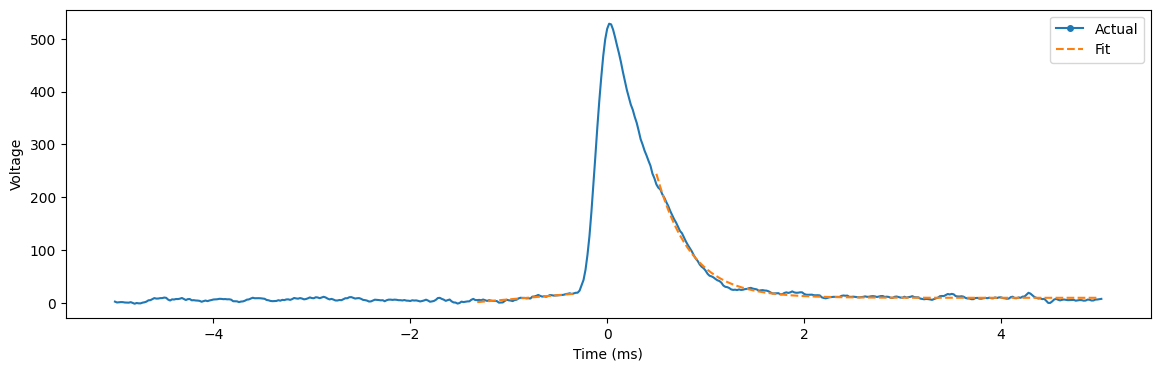

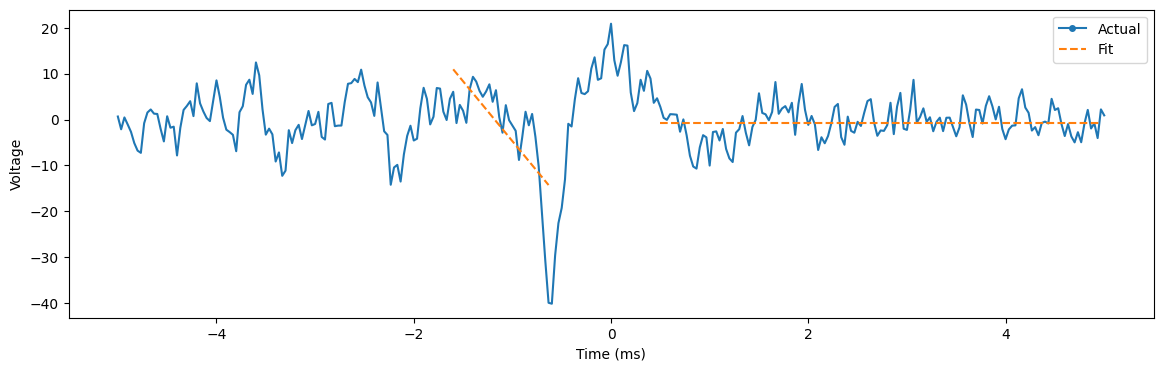

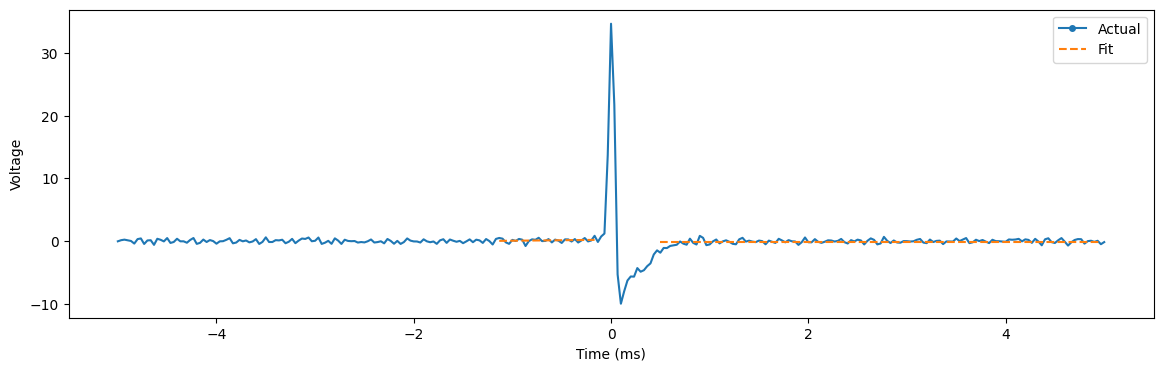

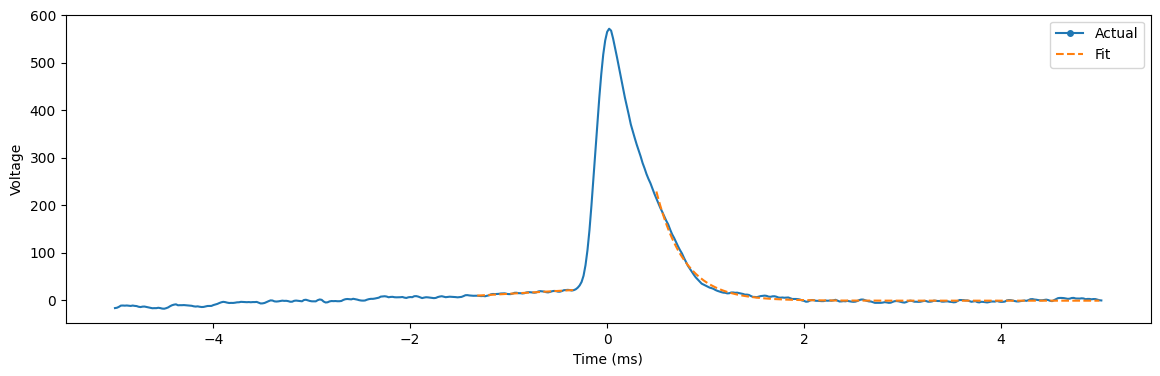

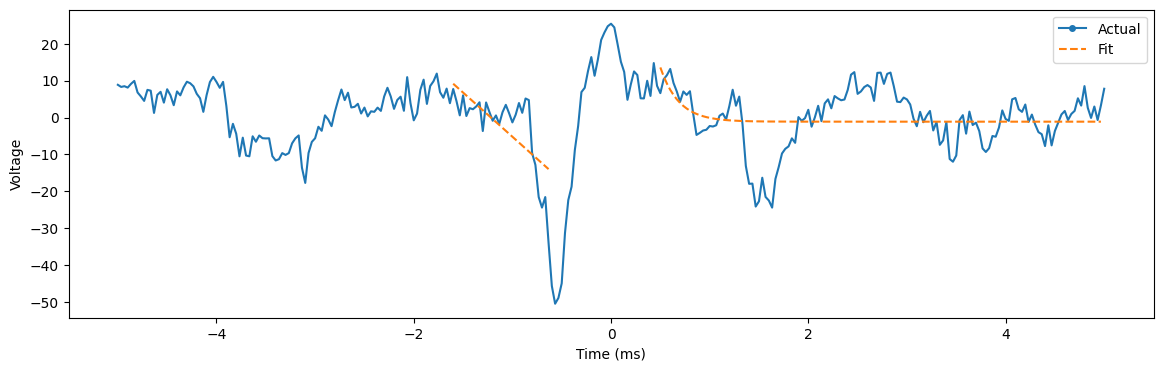

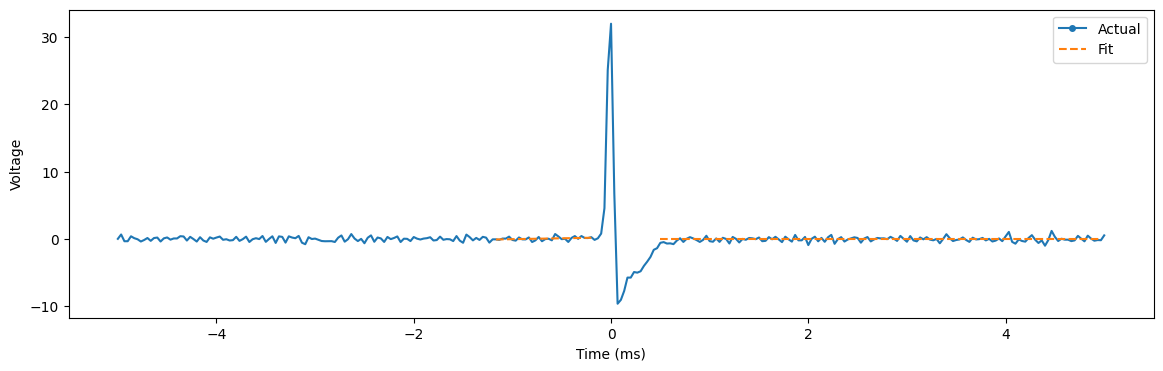

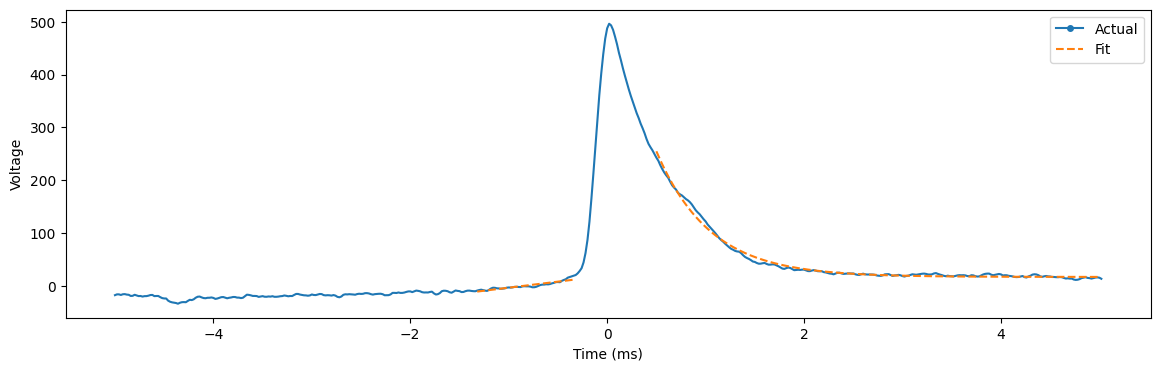

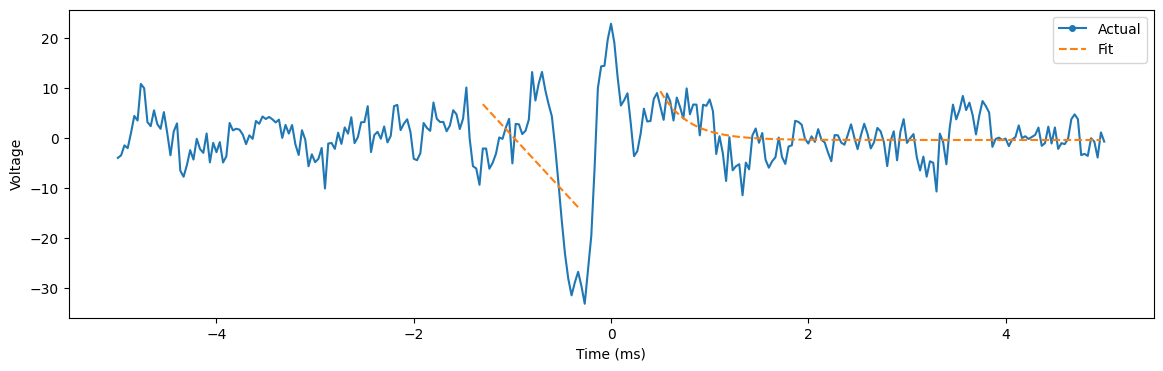

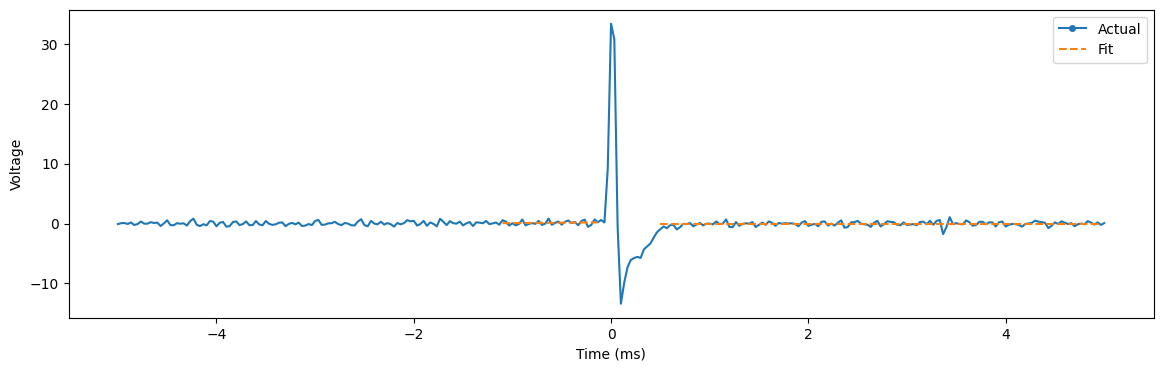

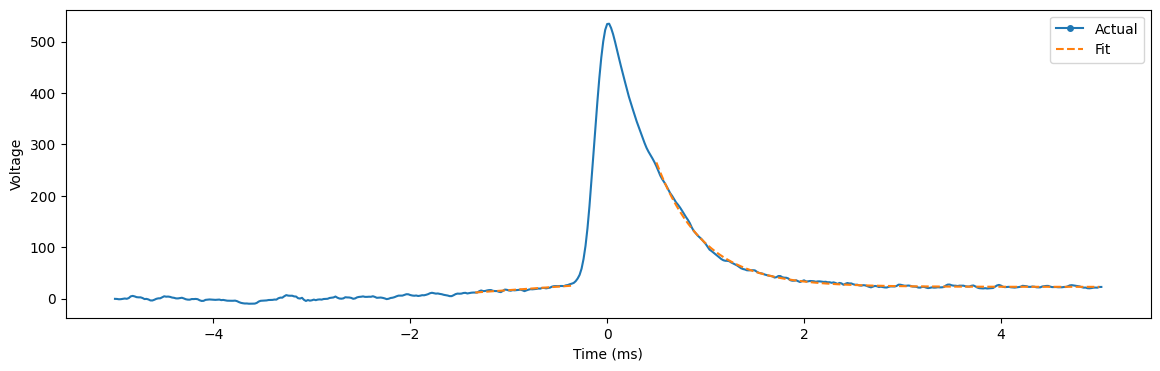

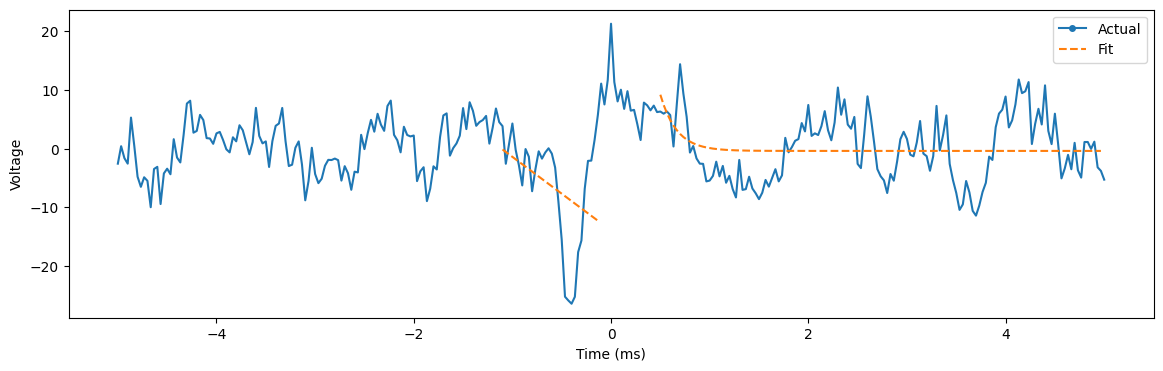

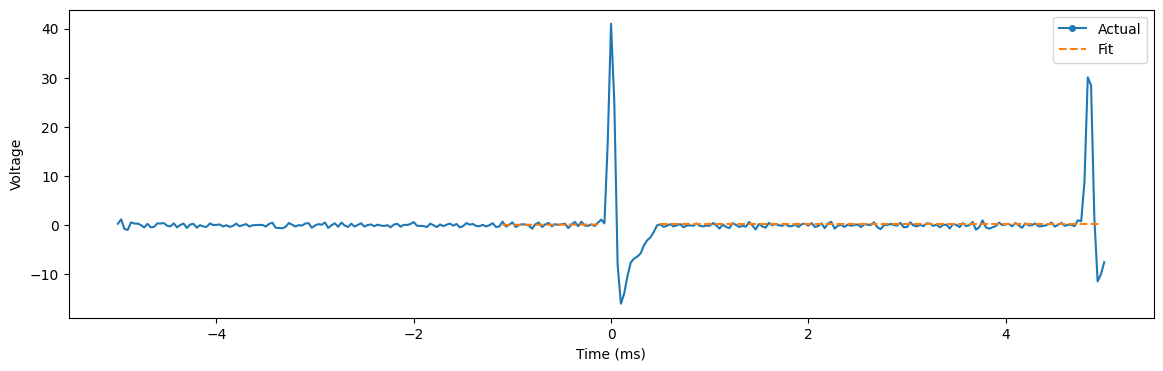

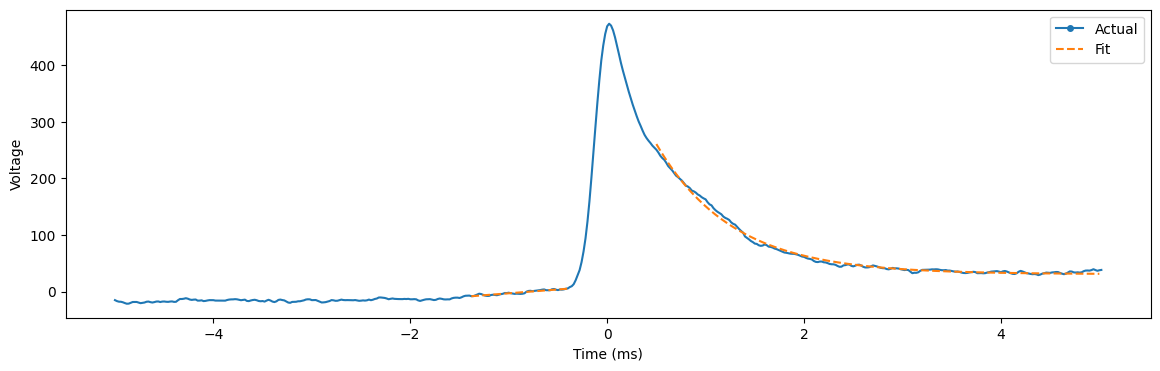

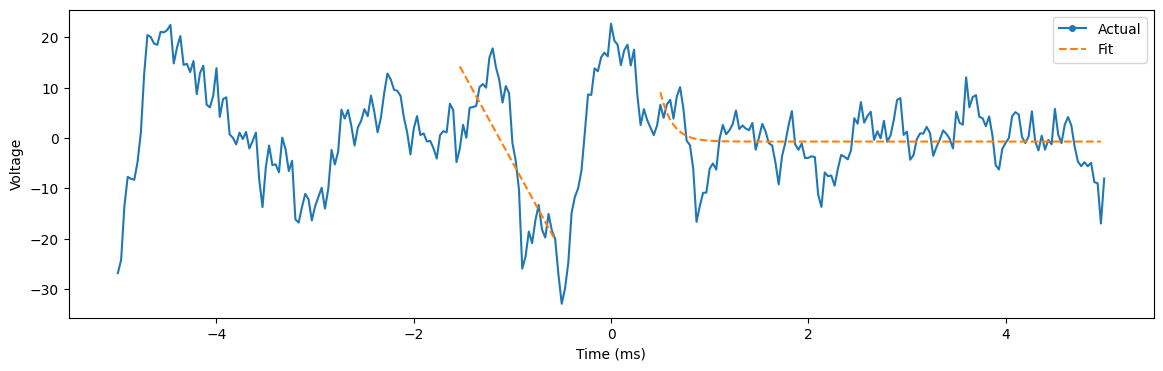

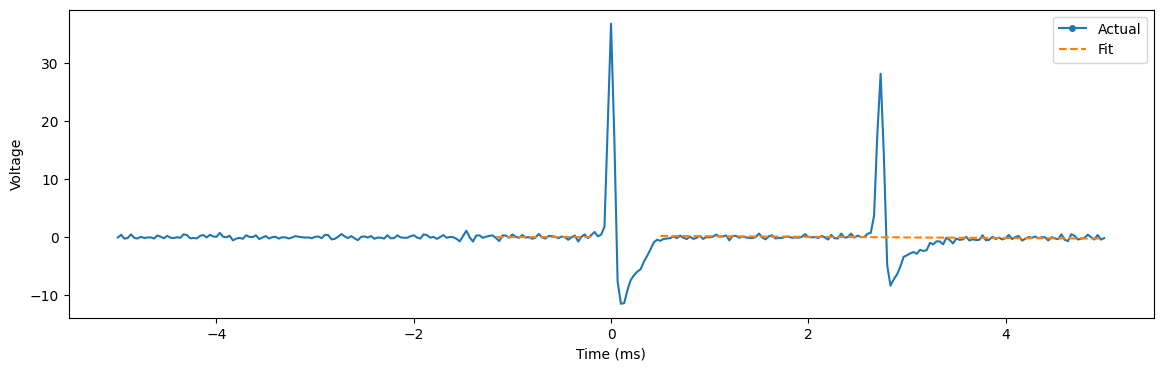

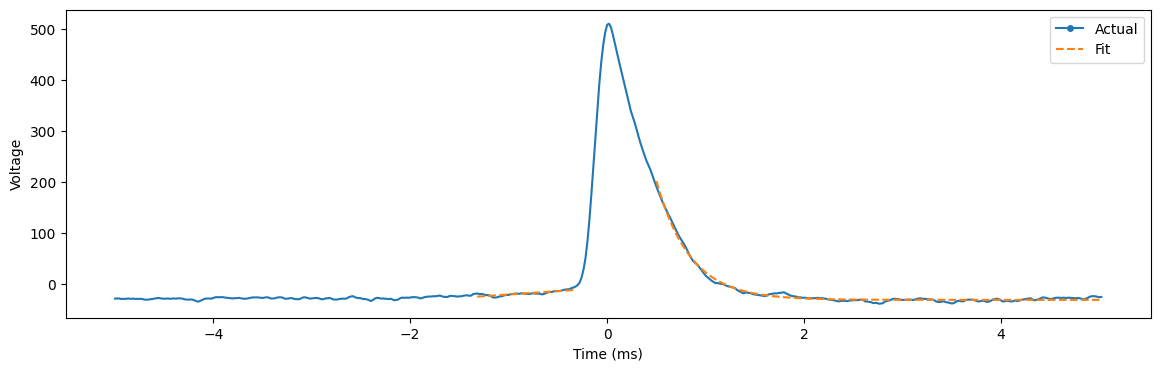

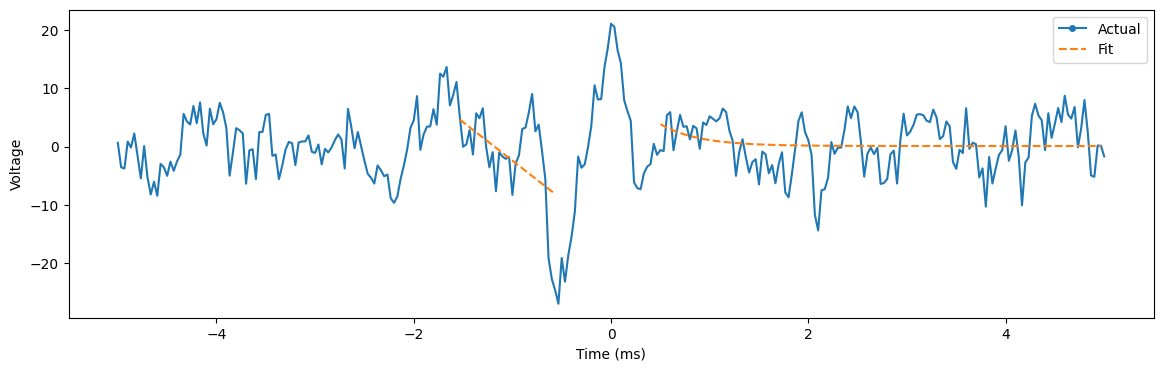

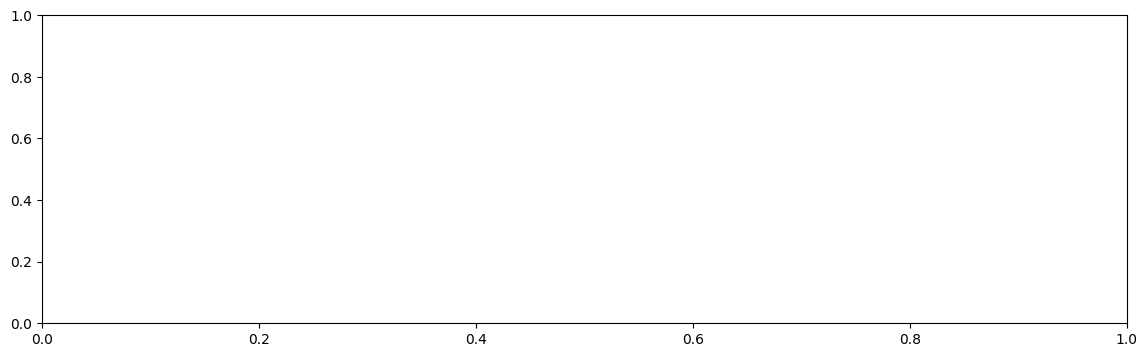

In [266]:

# Now, use the function to plot coincident spikes
#convert to indices 
coincident_iap_spikes_idx = [int(i*(patch_fs/1000)) for i in coincident_iap_spikes]

coincident_eap_spikes_idx = [int(i*(npx_fs/1000)) for i in coincident_eap_spikes]

coincident_inferred_eap_spikes_idx  = [int(i*(npx_fs/1000)) for i in coincident_iap_spikes]




# Now loop through the coincident spikes and plot them
for eap_spike_num, iap_spike_num, inferred_eap_spike_num in zip(coincident_eap_spike_num, coincident_iap_spike_num, coincident_iap_spike_num):
    
    
    # Plot for IAP spikes
    print(f"Plotting IAP spike at detected spike number: {iap_spike_num}")
    sp.plot(iap_spike_num)
    

    # Plot for EAP spikes
    print(f"Plotting EAP spike at detected spike number: {eap_spike_num}")
    sp_ex.plot(eap_spike_num)
    
    
    # Plot for Inferred EAP spikes
    print(f"Plotting Inferred EAP spike at detected spike number: {inferred_eap_spike_num}")
    sp_ex_inf.plot(inferred_eap_spike_num)

# EAP to inferred IAP